In [ ]:
# "C2H2" -> {"C": 2, "H": 2}

In [6]:
elements = {}
element_, element, count = "", "", ""
is_alpha, is_count = True, False
for l in "C2H2":
    if l.isalpha():
        if is_count:
            elements[element_] = count
            count = ""
        is_alpha, is_count = True, False
        element += l
    else:
        if is_alpha:
            element_ = element
            element = "" 
        is_alpha, is_count = False, True
        count += l
    elements[element_] = count
elements

{'C': '2', 'H': '2'}

In [ ]:
# "C2H2" -> ['C2', "H2"] 

In [7]:
"C2H2".split("2")

['C', 'H', '']

In [ ]:
regexp = r"\d[A-Z]"

In [8]:
"C2H2".split(r"\d[A-Z]")

['C2H2']

In [10]:
import re

re.split(r"\d[A-Z]", "C2H4")

['C', '4']

In [12]:
re.split(r"(?<=\d)(?=[A-Z])", "C2H4")

['C2', 'H4']

In [14]:
re.split(r"(?=[A-Z])", "C2H4")[1:]

['C2', 'H4']

In [19]:
# "Br24" -> ["Br", "24"]

re.split("(?=\d)", "Br24")

<unknown>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<ipython-input-19-e8d2c9051052>:3: SyntaxWarning: invalid escape sequence '\d'
  re.split("(?=\d)", "Br24")


['Br', '2', '4']

In [21]:
re.split(r"(?<=[A-Za-z])(?=\d)", "Br24")

['Br', '24']

In [27]:
formula = "K2MO4"
for e in re.split(r"(?<=[\d])(?=[A-Z])", formula):
    print(re.split(r"(?<=[A-Za-z])(?=\d)", e))

['K', '2']
['MO', '4']


In [29]:
formula = "K2MO4"
for e in re.split(r"(?<=[\d])(?=[A-Z])", formula):
    print(re.split(r"(?<=[A-Za-z])(?=\d)", e))

['K', '2']
['MO', '4']


In [30]:
formula = "K2MO4"
for e in re.split(r"(?<=[\da-z])(?=[A-Z])", formula):
    print(re.split(r"(?<=[A-Za-z])(?=\d)", e))

['K', '2']
['MO', '4']


In [39]:
formula = "K2MnO4"
for e in re.split(r"(?<=[\da-zA-Z])(?=[A-Z])", formula):
    print(re.split(r"(?<=[A-Za-z])(?=\d)", e))

['K', '2']
['Mn']
['O', '4']


In [38]:
formula = "K2MnO4"
for e in re.split(r"(?=[A-Z])", formula):
    print(re.split(r"(?<=[A-Za-z])(?=\d)", e))

['']
['K', '2']
['Mn']
['O', '4']


In [37]:
formula = "K2MnO4"
for e in re.split(r"(?=[A-Z])", formula)[1:]:
    print(re.split(r"(?<=[A-Za-z])(?=\d)", e))

['K', '2']
['Mn']
['O', '4']


In [42]:
re.findall(r"[A-Z][a-z]?\d*", "K2MnO4")

['K2', 'Mn', 'O4']

In [43]:
re.findall(r"([A-Z][a-z]?)(\d*)", "K2MnO4")

[('K', '2'), ('Mn', ''), ('O', '4')]

In [47]:
{
    e: int(c) if len(c) > 0 else 1
    for e, c
    in re.findall(r"([A-Z][a-z]?)(\d*)", "K2MnO4")
}

{'K': 2, 'Mn': 1, 'O': 4}

In [48]:
{
    e: int(c) if len(c) > 0 else 1
    for e, c
    in re.findall(r"([A-Z][a-z]?)(\d*)", "C2H5OH")
}

{'C': 2, 'H': 1, 'O': 1}

In [53]:
elems = {}
finds = re.findall(r"([A-Z][a-z]?)(\d*)", "C2H5OH")
for e, c in finds:
    c = int(c) if len(c) > 0 else 1
    elems[e] = (elems[e] + c) if e in elems else c
elems

{'C': 2, 'H': 6, 'O': 1}

In [54]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


In [55]:
%pip install chemparse

In [57]:
import chemparse; chemparse.parse_formula("C2H5OH")

{'C': 2.0, 'H': 6.0, 'O': 1.0}

In [69]:
import requests
r = requests.get(
    "https://cdn.lazarev.fun/data/"
    "const_vdv_pretty_with_mw.tsv"
)

r.content.decode("utf-8")[:50]

'Substance\tFormula\tConst_a\tConst_b\tMol_weight\nАзот\t'

In [64]:
from pathlib import Path
Path("const_vdv_pretty_with_mw.tsv") \
    .write_text(r.content.decode("utf-8"))

973

In [70]:
import pandas as pd
df = pd.read_csv(
    "const_vdv_pretty_with_mw.tsv", 
    sep="\t"
)
df.head()

,Substance,Formula,Const_a,Const_b,Mol_weight
0,Азот,N2,0.1370,38.7,28.014
1,Аммиак,NH3,0.4225,37.1,17.031
2,Аргон,Ar,0.1355,32.0,39.900
3,Ацетилен,C2H2,0.4516,52.2,26.040
4,Бром,Br2,0.9750,59.1,159.810


In [72]:
df.Formula.map(chemparse.parse_formula)[:3]

0              {'N': 2.0}
1    {'N': 1.0, 'H': 3.0}
2             {'Ar': 1.0}
Name: Formula, dtype: object

In [76]:
r = requests.get(
    "https://cdn.lazarev.fun/data/"
    "radii.json"
)
import json
radii = json.loads(r.text.replace("'", '"'))

In [77]:
from math import pi
def volume_by_formula(formula):
    volume = 0
    elems = chemparse.parse_formula(formula)
    for e, c in elems.items():
        volume += c * radii[e]**3 * 4 / 3 * pi
    return volume
volume_by_formula("C2H5OH")

4.705100485428361

In [79]:
df.Formula.map(volume_by_formula)[:1]

0    2.998428
Name: Formula, dtype: float64

In [81]:
df["Volume"] = df.Formula.map(volume_by_formula)
df.head()

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume
0,Азот,N2,0.1370,38.7,28.014,2.998428
1,Аммиак,NH3,0.4225,37.1,17.031,1.873579
2,Аргон,Ar,0.1355,32.0,39.900,4.988916
3,Ацетилен,C2H2,0.4516,52.2,26.040,3.001687
4,Бром,Br2,0.9750,59.1,159.810,14.476459


In [84]:
df.to_csv(
    "/drive/anm/data/"
    "const_vdv_pretty_with_mw_volume.tsv",
    sep="\t",
    index=False
)

In [86]:
%pip install seaborn

In [87]:
import seaborn

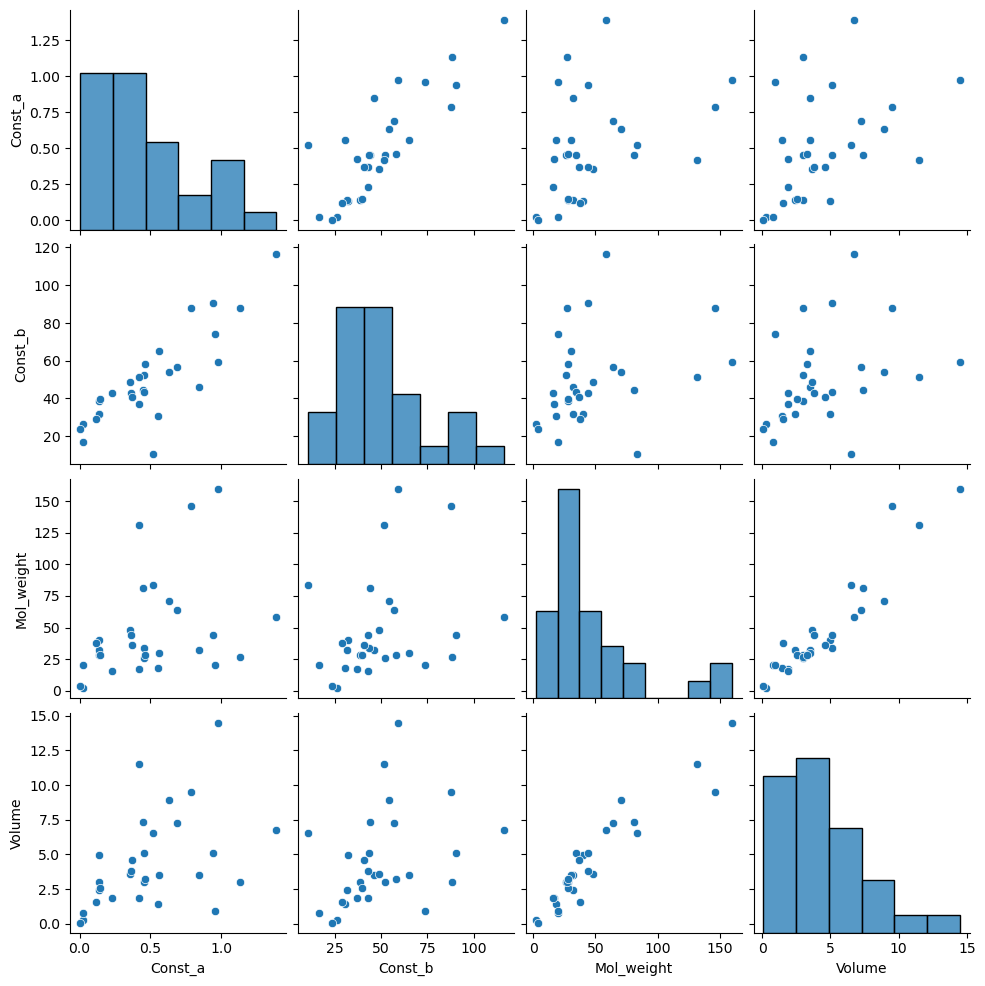

In [89]:
seaborn.pairplot(df)